# Notebook 04 — Explainability and Interpretable Rule Extraction for AMP Prediction

This notebook implements the explainability layer of the demonstrative antimicrobial peptide discovery workflow.

It assumes that **Notebook 03** has already generated:

- distance-aware train/validation/test splits,
- fixed baseline models,
- uncertainty-aware ensemble predictions,
- model artifacts and metadata.

The goal of this notebook is **not** to perform rule-based ranking yet. That will be done in the next notebook. Here, we only generate interpretable evidence that can later be converted into rule-aware scoring criteria.

## Main outputs

1. SHAP-based global feature importance.
2. SHAP-based local explanations for selected peptides.
3. Directionality analysis linking feature values with SHAP effects.
4. Candidate interpretable feature ranges associated with AMP-like predictions.
5. Shallow surrogate decision-tree rules for model-level interpretability.
6. Exported tables and figures for the manuscript and Supplementary Material.

In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from __future__ import annotations

import json
import warnings
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef

warnings.filterwarnings("ignore")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    shap = None

RANDOM_STATE = 42

TRAINING_DIR = Path("../outputs_training")
SPLIT_PATH = TRAINING_DIR / "splits" / "amp_model_ready_with_distance_aware_split.csv"
METADATA_PATH = TRAINING_DIR / "training_metadata.json"
BEST_MODEL_PATH = TRAINING_DIR / "best_model_selection.json"

OUTPUT_DIR = Path("../outputs_explainability")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
RULE_DIR = OUTPUT_DIR / "rules"

for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, RULE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SHAP_SAMPLE_SIZE = 1000
BACKGROUND_SAMPLE_SIZE = 300
TOP_N_FEATURES = 20
LOCAL_EXPLANATION_N = 20
SURROGATE_TREE_DEPTH = 4
SURROGATE_MIN_LEAF_FRACTION = 0.01

print(f"Run timestamp: {datetime.now().isoformat(timespec='seconds')}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Run timestamp: 2026-05-22T12:22:54
SHAP available: True
Output directory: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/outputs_explainability


## 2. Load training metadata, best model, and curated descriptor dataset

The notebook uses the best fixed baseline selected in Notebook 03 according to validation MCC. The same descriptor columns and split assignments are reused to avoid leakage or inconsistent preprocessing.

In [2]:
# ============================================================
# 2. Load metadata, best model, predictions, and descriptor table
# ============================================================

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Training metadata not found at {METADATA_PATH}. "
        "Please run Notebook 03 first."
    )

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model selection file not found at {BEST_MODEL_PATH}. "
        "Please run Notebook 03 first."
    )

if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"Split dataset not found at {SPLIT_PATH}. "
        "Please run Notebook 03 first."
    )

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

with open(BEST_MODEL_PATH, "r") as f:
    best_model_info = json.load(f)

SEQUENCE_COL = metadata.get("sequence_column", "sequence")
LABEL_COL = metadata.get("label_column", "label")
DESCRIPTOR_COLS = metadata["descriptor_columns"]
BEST_MODEL_NAME = best_model_info["best_model"]
BEST_MODEL_ARTIFACTS = best_model_info["artifacts"]

model_path = Path(BEST_MODEL_ARTIFACTS["final_model_path"])
prediction_path = Path(BEST_MODEL_ARTIFACTS["prediction_path"])

if not model_path.exists():
    raise FileNotFoundError(f"Best model artifact not found at {model_path}")

if not prediction_path.exists():
    raise FileNotFoundError(f"Prediction file not found at {prediction_path}")

model_df = pd.read_csv(SPLIT_PATH)
pred_df = pd.read_csv(prediction_path)

best_model = joblib.load(model_path)

print("Best model:", BEST_MODEL_NAME)
print("Model artifact:", model_path)
print("Prediction artifact:", prediction_path)
print("Dataset shape:", model_df.shape)
print("Number of descriptors:", len(DESCRIPTOR_COLS))

model_df.head()

Best model: extra_trees
Model artifact: ../outputs_training/models/extra_trees_final_model.joblib
Prediction artifact: ../outputs_training/predictions/extra_trees_predictions_with_uncertainty.csv
Dataset shape: (47175, 46)
Number of descriptors: 41


,sequence,label,label_name,length,shannon_entropy,normalized_entropy,unique_residue_fraction,net_charge_pH_7_4,absolute_charge_pH_7_4,isoelectric_point_approx,...,AAC_P,AAC_Q,AAC_R,AAC_S,AAC_T,AAC_V,AAC_W,AAC_Y,split,distance_cluster
0,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,1,AMP,38,3.081120,0.712904,0.315789,2.071371,2.071371,10.57,...,0.000000,0.263158,0.078947,0.000000,0.026316,0.026316,0.026316,0.000000,train,73
1,LHYNWIDCCHYGVSDCC,0,non-AMP,17,3.263933,0.755203,0.647059,-2.379134,2.379134,4.95,...,0.000000,0.000000,0.000000,0.058824,0.000000,0.058824,0.058824,0.117647,train,33
2,WDEDGAKRIPVDVSE,0,non-AMP,15,3.323231,0.768923,0.733333,-3.003945,3.003945,3.81,...,0.066667,0.000000,0.066667,0.066667,0.000000,0.133333,0.066667,0.000000,train,64
3,RQIKKAFRKMA,1,AMP,11,2.663533,0.616283,0.636364,4.992509,4.992509,12.00,...,0.000000,0.090909,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000,validation,4
4,MKIKTGARILALSALTTMMFSASALAK,0,non-AMP,27,3.105653,0.718580,0.370370,3.992517,3.992517,11.78,...,0.000000,0.000000,0.037037,0.111111,0.111111,0.000000,0.000000,0.000000,train,1


In [3]:
# ============================================================
# 3. Build analysis matrix and merge uncertainty-aware predictions
# ============================================================

required_prediction_cols = [SEQUENCE_COL, "probability_amp_ensemble", "uncertainty_std", "prediction"]
missing_pred_cols = [c for c in required_prediction_cols if c not in pred_df.columns]
if missing_pred_cols:
    raise ValueError(f"Missing required prediction columns: {missing_pred_cols}")

analysis_df = model_df.merge(
    pred_df[required_prediction_cols],
    on=SEQUENCE_COL,
    how="left",
)

if analysis_df["probability_amp_ensemble"].isna().any():
    n_missing = int(analysis_df["probability_amp_ensemble"].isna().sum())
    raise ValueError(f"Missing predictions after merge for {n_missing} sequences.")

for col in DESCRIPTOR_COLS:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

X = analysis_df[DESCRIPTOR_COLS].copy()
y = analysis_df[LABEL_COL].astype(int).values

train_df = analysis_df[analysis_df["split"].eq("train")].copy()
validation_df = analysis_df[analysis_df["split"].eq("validation")].copy()
test_df = analysis_df[analysis_df["split"].eq("test")].copy()

X_train = train_df[DESCRIPTOR_COLS].copy()
y_train = train_df[LABEL_COL].astype(int).values

X_validation = validation_df[DESCRIPTOR_COLS].copy()
X_test = test_df[DESCRIPTOR_COLS].copy()

print("Split sizes:")
print(analysis_df["split"].value_counts())

analysis_df[[SEQUENCE_COL, LABEL_COL, "split", "probability_amp_ensemble", "uncertainty_std"]].head()

Split sizes:
split
train         33022
validation     9435
test           4718
Name: count, dtype: int64


,sequence,label,split,probability_amp_ensemble,uncertainty_std
0,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,1,train,0.970600,0.088200
1,LHYNWIDCCHYGVSDCC,0,train,0.019200,0.057600
2,WDEDGAKRIPVDVSE,0,train,0.005200,0.015600
3,RQIKKAFRKMA,1,validation,0.695702,0.023033
4,MKIKTGARILALSALTTMMFSASALAK,0,train,0.007000,0.021000


## 3. Prepare SHAP input space

The trained model is a scikit-learn pipeline containing imputation, z-score scaling, and the final classifier. SHAP is computed in the transformed descriptor space, while interpretation tables also retain the raw descriptor values to make downstream rules easier to define.

In [4]:
# ============================================================
# 4. Transform descriptors using the trained preprocessing pipeline
# ============================================================

if not hasattr(best_model, "named_steps") or "model" not in best_model.named_steps:
    raise TypeError("Expected a scikit-learn Pipeline with a final step named 'model'.")

preprocessor = best_model[:-1]
classifier = best_model.named_steps["model"]

X_train_scaled = pd.DataFrame(
    preprocessor.transform(X_train),
    columns=DESCRIPTOR_COLS,
    index=X_train.index,
)

X_all_scaled = pd.DataFrame(
    preprocessor.transform(X),
    columns=DESCRIPTOR_COLS,
    index=analysis_df.index,
)

# Use a stratified and size-controlled sample for SHAP to keep the notebook fast.
def stratified_sample_indices(df: pd.DataFrame, label_col: str, n: int, random_state: int) -> np.ndarray:
    if len(df) <= n:
        return df.index.to_numpy()
    sampled = []
    per_class = max(1, n // df[label_col].nunique())
    for _, group in df.groupby(label_col):
        sampled.append(group.sample(n=min(per_class, len(group)), random_state=random_state))
    sampled_df = pd.concat(sampled, axis=0)
    if len(sampled_df) < n:
        remaining = df.drop(index=sampled_df.index)
        extra = remaining.sample(n=min(n - len(sampled_df), len(remaining)), random_state=random_state)
        sampled_df = pd.concat([sampled_df, extra], axis=0)
    return sampled_df.index.to_numpy()

shap_indices = stratified_sample_indices(
    analysis_df,
    label_col=LABEL_COL,
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

background_indices = stratified_sample_indices(
    train_df,
    label_col=LABEL_COL,
    n=BACKGROUND_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

X_shap_raw = X.loc[shap_indices].copy()
X_shap_scaled = X_all_scaled.loc[shap_indices].copy()
shap_meta_df = analysis_df.loc[shap_indices, [SEQUENCE_COL, LABEL_COL, "split", "probability_amp_ensemble", "uncertainty_std"]].copy()

X_background_scaled = X_all_scaled.loc[background_indices].copy()

print("Classifier:", classifier.__class__.__name__)
print("SHAP sample size:", X_shap_scaled.shape)
print("Background sample size:", X_background_scaled.shape)

Classifier: ExtraTreesClassifier
SHAP sample size: (1000, 41)
Background sample size: (300, 41)


## 4. SHAP computation

The code automatically uses a tree explainer for tree-based models and a linear explainer for logistic regression. For other model classes, the notebook falls back to a model-agnostic explainer on a reduced background sample.

In [5]:
# ============================================================
# 5. Compute SHAP values for the positive AMP class
# ============================================================

if not SHAP_AVAILABLE:
    raise ImportError(
        "The 'shap' package is not installed. Install it with `pip install shap` "
        "or run this notebook in an environment where SHAP is available."
    )


def extract_positive_class_shap_values(values):
    # Return SHAP values associated with the positive class from different SHAP formats.
    if isinstance(values, list):
        if len(values) == 1:
            return values[0]
        return values[1]
    arr = np.asarray(values)
    if arr.ndim == 3:
        # SHAP may return shape: samples x features x classes
        if arr.shape[-1] == 2:
            return arr[:, :, 1]
        # Or classes x samples x features
        if arr.shape[0] == 2:
            return arr[1, :, :]
    return arr

classifier_name = classifier.__class__.__name__.lower()

if "forest" in classifier_name or "extra" in classifier_name or "tree" in classifier_name:
    explainer = shap.TreeExplainer(classifier)
    raw_shap_values = explainer.shap_values(X_shap_scaled)
    shap_values = extract_positive_class_shap_values(raw_shap_values)
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)) and len(np.atleast_1d(expected_value)) > 1:
        expected_value = np.atleast_1d(expected_value)[1]

elif "logistic" in classifier_name or "linear" in classifier_name:
    explainer = shap.LinearExplainer(classifier, X_background_scaled)
    raw_shap_values = explainer.shap_values(X_shap_scaled)
    shap_values = extract_positive_class_shap_values(raw_shap_values)
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)) and len(np.atleast_1d(expected_value)) > 1:
        expected_value = np.atleast_1d(expected_value)[1]

else:
    # Conservative fallback. This may be slower, so use a smaller background by default.
    background_small = shap.sample(X_background_scaled, min(100, len(X_background_scaled)), random_state=RANDOM_STATE)
    explainer = shap.Explainer(classifier.predict_proba, background_small)
    explanation = explainer(X_shap_scaled)
    shap_values = extract_positive_class_shap_values(explanation.values)
    expected_value = explanation.base_values

shap_values = np.asarray(shap_values)

if shap_values.shape != X_shap_scaled.shape:
    raise ValueError(
        f"Unexpected SHAP shape {shap_values.shape}; expected {X_shap_scaled.shape}. "
        "Please inspect SHAP output format for this model."
    )

shap_values_df = pd.DataFrame(
    shap_values,
    columns=DESCRIPTOR_COLS,
    index=X_shap_scaled.index,
)

print("SHAP values shape:", shap_values_df.shape)
print("Expected value:", expected_value)

SHAP values shape: (1000, 41)
Expected value: 0.5000000000000048


In [6]:
# ============================================================
# 6. Export raw SHAP values and SHAP analysis matrix
# ============================================================

shap_matrix = pd.concat(
    [
        shap_meta_df.reset_index(drop=True),
        X_shap_raw.reset_index(drop=True).add_prefix("raw__"),
        shap_values_df.reset_index(drop=True).add_prefix("shap__"),
    ],
    axis=1,
)

shap_matrix_path = TABLE_DIR / "shap_values_matrix.csv"
shap_matrix.to_csv(shap_matrix_path, index=False)

print("Saved:", shap_matrix_path)
shap_matrix.head()

Saved: ../outputs_explainability/tables/shap_values_matrix.csv


,sequence,label,split,probability_amp_ensemble,uncertainty_std,raw__length,raw__shannon_entropy,raw__normalized_entropy,raw__unique_residue_fraction,raw__net_charge_pH_7_4,...,shap__AAC_M,shap__AAC_N,shap__AAC_P,shap__AAC_Q,shap__AAC_R,shap__AAC_S,shap__AAC_T,shap__AAC_V,shap__AAC_W,shap__AAC_Y
0,IPEPYVWD,0,validation,0.151386,0.010786,8,2.750000,0.636290,0.875000,-2.006268,...,0.010401,-0.001282,-0.033056,-0.000122,-0.001133,0.006471,-0.004138,0.000087,0.026119,-0.007141
1,MARLLTTCCLLALLLAACTDVALSK,0,validation,0.056200,0.007922,25,2.839080,0.656901,0.400000,0.658973,...,-0.060593,-0.006211,0.005076,0.000437,-0.008990,0.001697,-0.005455,-0.003694,-0.007368,-0.001274
2,VCCSFGSCDSLCQCCDGLAPNIHGAVLGGFIRTMSAFVDFTYHCATSLV,0,train,0.038400,0.115200,49,3.811025,0.881788,0.346939,-2.712282,...,-0.027640,-0.007203,-0.004736,-0.003951,-0.004695,-0.022262,-0.007390,-0.005216,-0.011455,-0.005831
3,MTISASDYRHPGNFLKRTTALLCVGTALTALAFNASAA,0,train,0.019200,0.057600,38,3.669660,0.849079,0.447368,1.918892,...,-0.047683,-0.001487,-0.002181,-0.003326,-0.014983,-0.013925,-0.011240,-0.009179,-0.013703,-0.004954
4,VKCFR,0,train,0.060800,0.182400,5,2.321928,0.537244,1.000000,1.882289,...,0.006537,-0.000720,0.006187,0.001104,-0.019496,0.001046,-0.003363,-0.028484,-0.018078,-0.002275


## 5. Global SHAP importance and directionality

The following table ranks descriptors by mean absolute SHAP value. A directionality score is also estimated by correlating raw descriptor values with their SHAP contribution. Positive correlations suggest that larger feature values tend to push predictions toward the AMP class; negative correlations suggest the opposite.

In [7]:
# ============================================================
# 7. Global SHAP importance and directionality analysis
# ============================================================

importance_rows = []

for feature in DESCRIPTOR_COLS:
    shap_feature = shap_values_df[feature].values
    raw_feature = X_shap_raw[feature].values

    valid = np.isfinite(shap_feature) & np.isfinite(raw_feature)
    if valid.sum() >= 5:
        rho, p_value = spearmanr(raw_feature[valid], shap_feature[valid])
    else:
        rho, p_value = np.nan, np.nan

    if pd.isna(rho):
        direction = "undetermined"
    elif rho > 0.15:
        direction = "higher_values_support_AMP_prediction"
    elif rho < -0.15:
        direction = "lower_values_support_AMP_prediction"
    else:
        direction = "non_monotonic_or_weak_direction"

    importance_rows.append({
        "feature": feature,
        "mean_abs_shap": float(np.nanmean(np.abs(shap_feature))),
        "mean_shap": float(np.nanmean(shap_feature)),
        "median_shap": float(np.nanmedian(shap_feature)),
        "spearman_raw_value_vs_shap": float(rho) if not pd.isna(rho) else np.nan,
        "spearman_p_value": float(p_value) if not pd.isna(p_value) else np.nan,
        "interpretable_direction": direction,
        "raw_median": float(np.nanmedian(raw_feature)),
        "raw_q25": float(np.nanpercentile(raw_feature, 25)),
        "raw_q75": float(np.nanpercentile(raw_feature, 75)),
    })

global_importance_df = (
    pd.DataFrame(importance_rows)
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

global_importance_path = TABLE_DIR / "shap_global_importance_directionality.csv"
global_importance_df.to_csv(global_importance_path, index=False)

print("Saved:", global_importance_path)
global_importance_df.head(TOP_N_FEATURES)

Saved: ../outputs_explainability/tables/shap_global_importance_directionality.csv


,feature,mean_abs_shap,mean_shap,median_shap,spearman_raw_value_vs_shap,spearman_p_value,interpretable_direction,raw_median,raw_q25,raw_q75
0,AAC_K,0.044008,0.002915,-0.012617,0.850375,1.450929e-280,higher_values_support_AMP_prediction,0.051282,0.000000,0.133333
1,AAC_M,0.035435,-0.000409,0.014601,-0.825355,5.410361e-250,lower_values_support_AMP_prediction,0.000000,0.000000,0.035244
2,isoelectric_point_approx,0.032766,0.003684,0.006249,0.538873,2.140046e-76,higher_values_support_AMP_prediction,9.910000,6.020000,11.220000
3,positive_fraction,0.030998,0.001587,-0.008039,0.851123,1.457752e-281,higher_values_support_AMP_prediction,0.153846,0.088106,0.263158
4,small_fraction,0.020585,-0.000705,-0.007268,-0.726056,1.675945e-164,lower_values_support_AMP_prediction,0.500000,0.357143,0.592593
5,polar_fraction,0.018879,-0.001109,-0.004768,-0.779280,9.108957e-205,lower_values_support_AMP_prediction,0.222222,0.125000,0.333333
6,unique_residue_fraction,0.018787,-0.000580,0.000999,-0.728051,7.753426e-166,lower_values_support_AMP_prediction,0.516685,0.380952,0.666667
7,AAC_S,0.018572,-0.000430,0.003952,-0.783227,3.361839e-208,lower_values_support_AMP_prediction,0.045455,0.000000,0.100000
8,net_charge_pH_7_4,0.017311,-0.000468,-0.001618,0.771348,4.430871e-198,higher_values_support_AMP_prediction,1.338777,-0.009076,3.992259
9,charged_fraction,0.016490,-0.000920,-0.000891,0.738873,2.731323e-173,higher_values_support_AMP_prediction,0.226136,0.150000,0.333333


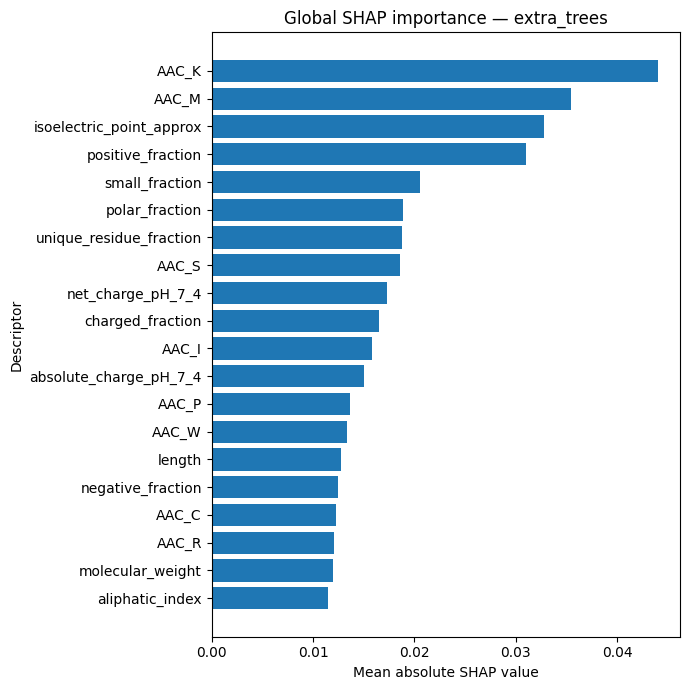

Saved: ../outputs_explainability/figures/shap_global_importance_barplot.png


In [8]:
# ============================================================
# 8. Plot global SHAP feature importance
# ============================================================

top_importance = global_importance_df.head(TOP_N_FEATURES).iloc[::-1]

plt.figure(figsize=(7, max(4, 0.35 * len(top_importance))))
plt.barh(top_importance["feature"], top_importance["mean_abs_shap"])
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Descriptor")
plt.title(f"Global SHAP importance — {BEST_MODEL_NAME}")
plt.tight_layout()

importance_fig_path = FIGURE_DIR / "shap_global_importance_barplot.png"
plt.savefig(importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", importance_fig_path)

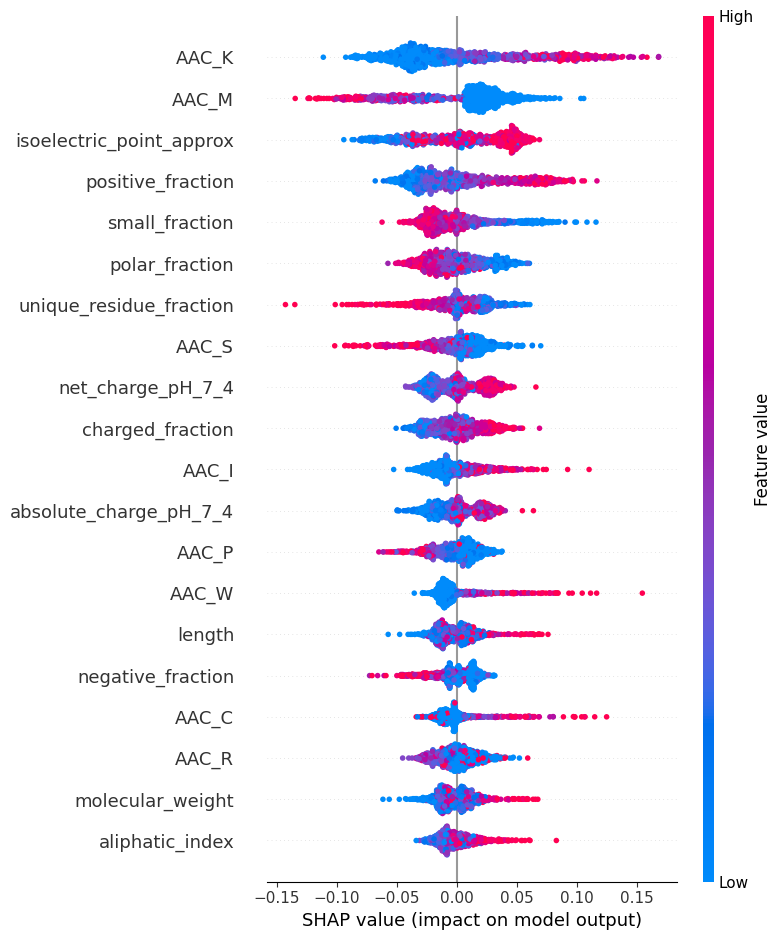

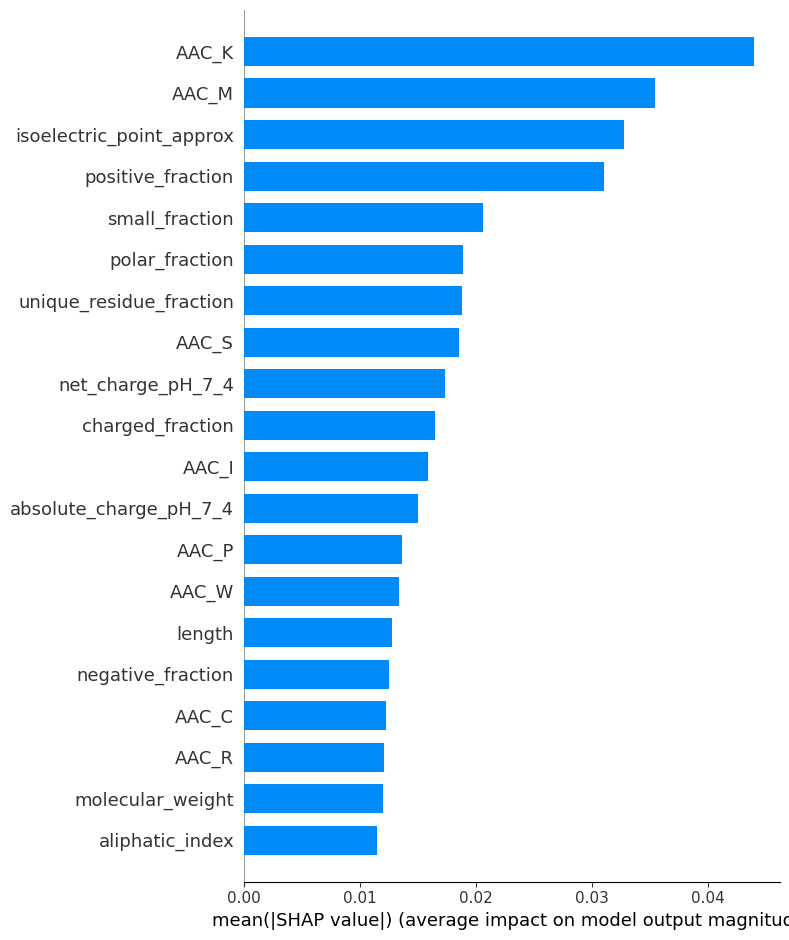

Saved: ../outputs_explainability/figures/shap_summary_beeswarm.png
Saved: ../outputs_explainability/figures/shap_summary_bar.png


In [9]:
# ============================================================
# 9. SHAP summary plots
# ============================================================

# Beeswarm-like summary plot. In non-interactive environments this may be slower for large matrices.
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap_raw,
    feature_names=DESCRIPTOR_COLS,
    max_display=TOP_N_FEATURES,
    show=False,
)
plt.tight_layout()
summary_fig_path = FIGURE_DIR / "shap_summary_beeswarm.png"
plt.savefig(summary_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Bar summary plot.
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap_raw,
    feature_names=DESCRIPTOR_COLS,
    plot_type="bar",
    max_display=TOP_N_FEATURES,
    show=False,
)
plt.tight_layout()
summary_bar_fig_path = FIGURE_DIR / "shap_summary_bar.png"
plt.savefig(summary_bar_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", summary_fig_path)
print("Saved:", summary_bar_fig_path)

## 6. Feature-level dependence plots

These plots help identify how individual descriptors influence the model output. They are useful for converting SHAP evidence into candidate soft rules in the next notebook.

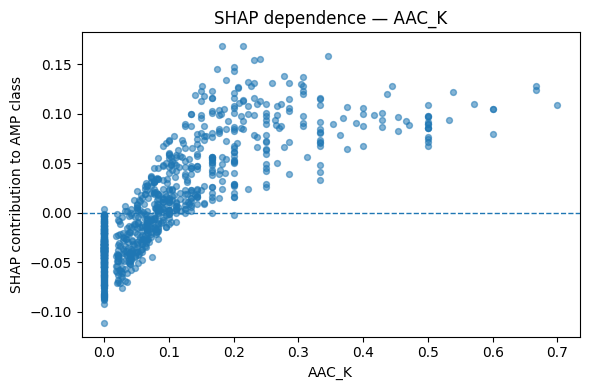

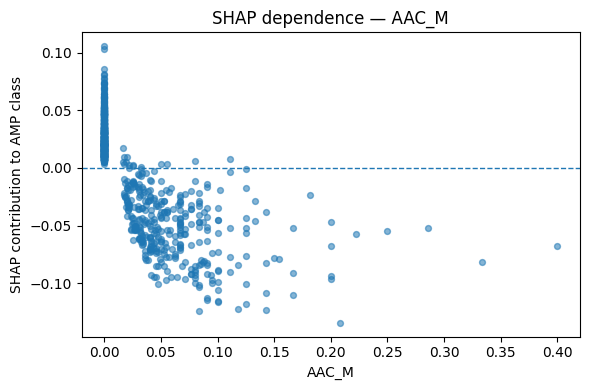

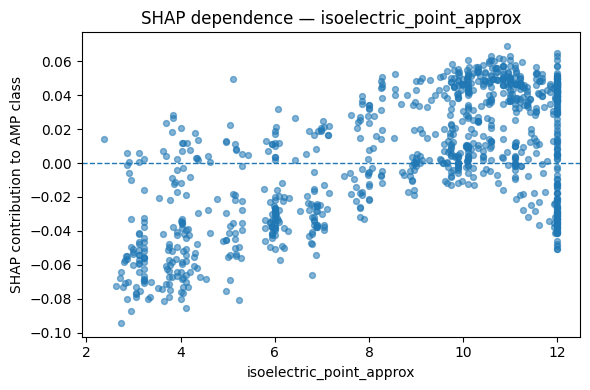

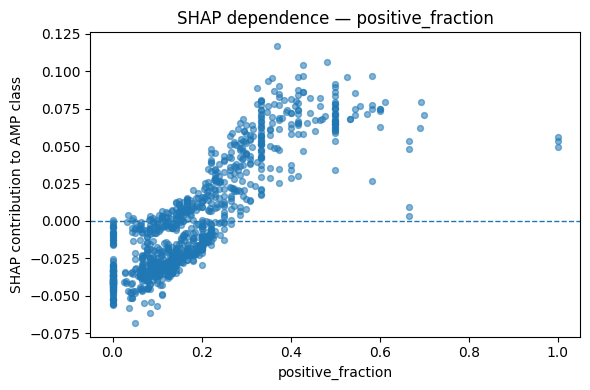

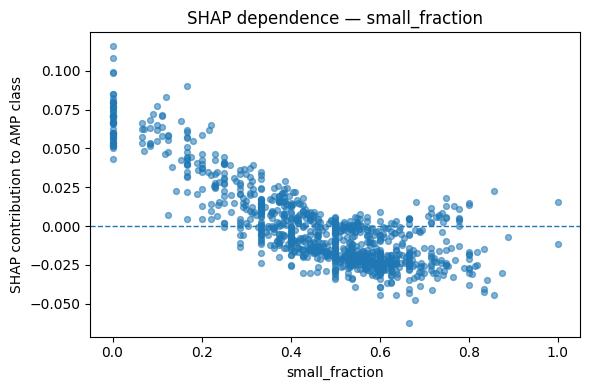

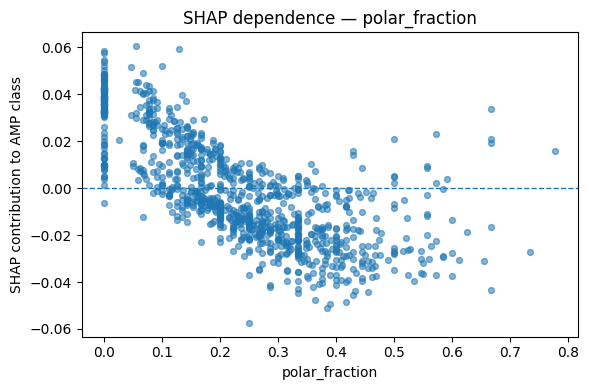

Generated dependence plots for: ['AAC_K', 'AAC_M', 'isoelectric_point_approx', 'positive_fraction', 'small_fraction', 'polar_fraction']


In [10]:
# ============================================================
# 10. Dependence plots for top SHAP features
# ============================================================

top_features = global_importance_df.head(min(6, TOP_N_FEATURES))["feature"].tolist()

for feature in top_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(
        X_shap_raw[feature],
        shap_values_df[feature],
        alpha=0.55,
        s=18,
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel(feature)
    plt.ylabel("SHAP contribution to AMP class")
    plt.title(f"SHAP dependence — {feature}")
    plt.tight_layout()

    fig_path = FIGURE_DIR / f"shap_dependence_{feature}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

print("Generated dependence plots for:", top_features)

## 7. Local explanations for high-confidence and uncertain peptides

This section exports local explanations for representative peptides. These examples are useful for the manuscript because they show how the model justifies individual decisions and where uncertainty may complicate prioritisation.

In [11]:
# ============================================================
# 11. Select representative peptides for local explanations
# ============================================================

local_df = shap_meta_df.copy()
local_df["abs_distance_from_0_5"] = (local_df["probability_amp_ensemble"] - 0.5).abs()

# High-confidence AMP-like examples: high probability and low uncertainty.
uncertainty_cutoff_low = local_df["uncertainty_std"].quantile(0.25)
high_conf_amp = (
    local_df[local_df["probability_amp_ensemble"].ge(0.80) & local_df["uncertainty_std"].le(uncertainty_cutoff_low)]
    .sort_values(["probability_amp_ensemble", "uncertainty_std"], ascending=[False, True])
    .head(LOCAL_EXPLANATION_N // 2)
)

# Ambiguous examples: close to decision boundary or high uncertainty.
uncertainty_cutoff_high = local_df["uncertainty_std"].quantile(0.75)
ambiguous = (
    local_df[local_df["uncertainty_std"].ge(uncertainty_cutoff_high)]
    .sort_values(["uncertainty_std", "abs_distance_from_0_5"], ascending=[False, True])
    .head(LOCAL_EXPLANATION_N // 2)
)

selected_local = pd.concat([high_conf_amp, ambiguous], axis=0).drop_duplicates(subset=[SEQUENCE_COL])
selected_indices = selected_local.index.to_numpy()

print("Selected local explanations:", len(selected_indices))
selected_local[[SEQUENCE_COL, LABEL_COL, "split", "probability_amp_ensemble", "uncertainty_std"]].head()

Selected local explanations: 20


,sequence,label,split,probability_amp_ensemble,uncertainty_std
28011,LKKKKKKFLQ,1,validation,1.0,0.0
28616,LLKKLLKK,1,test,1.0,0.0
1608,KKKLFKKKLQ,1,train,1.0,0.0
37265,FKVKFKVKVK,1,validation,1.0,0.0
14284,WWRRRW,1,validation,1.0,0.0


In [12]:
# ============================================================
# 12. Export local top-contributing SHAP features per selected peptide
# ============================================================

local_rows = []

for idx in selected_indices:
    seq = analysis_df.loc[idx, SEQUENCE_COL]
    local_values = shap_values_df.loc[idx]
    raw_values = X_shap_raw.loc[idx]

    top_pos = local_values.sort_values(ascending=False).head(5)
    top_neg = local_values.sort_values(ascending=True).head(5)

    for rank, (feature, value) in enumerate(top_pos.items(), start=1):
        local_rows.append({
            "sequence": seq,
            "label": int(analysis_df.loc[idx, LABEL_COL]),
            "split": analysis_df.loc[idx, "split"],
            "probability_amp_ensemble": float(analysis_df.loc[idx, "probability_amp_ensemble"]),
            "uncertainty_std": float(analysis_df.loc[idx, "uncertainty_std"]),
            "contribution_type": "supports_AMP_prediction",
            "rank": rank,
            "feature": feature,
            "raw_feature_value": float(raw_values[feature]),
            "shap_value": float(value),
        })

    for rank, (feature, value) in enumerate(top_neg.items(), start=1):
        local_rows.append({
            "sequence": seq,
            "label": int(analysis_df.loc[idx, LABEL_COL]),
            "split": analysis_df.loc[idx, "split"],
            "probability_amp_ensemble": float(analysis_df.loc[idx, "probability_amp_ensemble"]),
            "uncertainty_std": float(analysis_df.loc[idx, "uncertainty_std"]),
            "contribution_type": "opposes_AMP_prediction",
            "rank": rank,
            "feature": feature,
            "raw_feature_value": float(raw_values[feature]),
            "shap_value": float(value),
        })

local_explanations_df = pd.DataFrame(local_rows)
local_explanations_path = TABLE_DIR / "local_shap_explanations_selected_peptides.csv"
local_explanations_df.to_csv(local_explanations_path, index=False)

print("Saved:", local_explanations_path)
local_explanations_df.head(15)

Saved: ../outputs_explainability/tables/local_shap_explanations_selected_peptides.csv


,sequence,label,split,probability_amp_ensemble,uncertainty_std,contribution_type,rank,feature,raw_feature_value,shap_value
0,LKKKKKKFLQ,1,validation,1.0,0.0,supports_AMP_prediction,1,AAC_K,0.600000,0.104367
1,LKKKKKKFLQ,1,validation,1.0,0.0,supports_AMP_prediction,2,small_fraction,0.000000,0.079265
2,LKKKKKKFLQ,1,validation,1.0,0.0,supports_AMP_prediction,3,positive_fraction,0.600000,0.074570
3,LKKKKKKFLQ,1,validation,1.0,0.0,supports_AMP_prediction,4,isoelectric_point_approx,11.210000,0.047149
4,LKKKKKKFLQ,1,validation,1.0,0.0,supports_AMP_prediction,5,net_charge_pH_7_4,5.990144,0.029668
5,LKKKKKKFLQ,1,validation,1.0,0.0,opposes_AMP_prediction,1,AAC_Q,0.100000,-0.018929
6,LKKKKKKFLQ,1,validation,1.0,0.0,opposes_AMP_prediction,2,instability_proxy,70.000000,-0.015274
7,LKKKKKKFLQ,1,validation,1.0,0.0,opposes_AMP_prediction,3,AAC_I,0.000000,-0.008901
8,LKKKKKKFLQ,1,validation,1.0,0.0,opposes_AMP_prediction,4,AAC_W,0.000000,-0.008643
9,LKKKKKKFLQ,1,validation,1.0,0.0,opposes_AMP_prediction,5,sheet_propensity,0.939000,-0.006068


## 8. Extract candidate interpretable feature ranges

Here, we identify descriptor ranges enriched among confident AMP-like predictions. These are not final design rules yet. They are exported as candidate evidence for the next notebook, where rule-based scoring will be defined and evaluated.

In [13]:
# ============================================================
# 13. Candidate interpretable feature ranges for rule-based scoring
# ============================================================

prob_cutoff = 0.80
uncertainty_cutoff = analysis_df["uncertainty_std"].quantile(0.25)

confident_amp_like_df = analysis_df[
    analysis_df["probability_amp_ensemble"].ge(prob_cutoff)
    & analysis_df["uncertainty_std"].le(uncertainty_cutoff)
].copy()

if confident_amp_like_df.empty:
    # Conservative fallback if the model is not very confident.
    prob_cutoff = analysis_df["probability_amp_ensemble"].quantile(0.90)
    uncertainty_cutoff = analysis_df["uncertainty_std"].quantile(0.50)
    confident_amp_like_df = analysis_df[
        analysis_df["probability_amp_ensemble"].ge(prob_cutoff)
        & analysis_df["uncertainty_std"].le(uncertainty_cutoff)
    ].copy()

rule_rows = []

for feature in global_importance_df.head(TOP_N_FEATURES)["feature"]:
    all_values = analysis_df[feature].astype(float)
    selected_values = confident_amp_like_df[feature].astype(float)

    direction = global_importance_df.loc[global_importance_df["feature"].eq(feature), "interpretable_direction"].iloc[0]

    if selected_values.notna().sum() == 0:
        continue

    selected_q10 = selected_values.quantile(0.10)
    selected_q25 = selected_values.quantile(0.25)
    selected_median = selected_values.median()
    selected_q75 = selected_values.quantile(0.75)
    selected_q90 = selected_values.quantile(0.90)

    background_median = all_values.median()
    background_q25 = all_values.quantile(0.25)
    background_q75 = all_values.quantile(0.75)

    if direction == "higher_values_support_AMP_prediction":
        candidate_rule = f"{feature} >= {selected_q25:.4g}"
    elif direction == "lower_values_support_AMP_prediction":
        candidate_rule = f"{feature} <= {selected_q75:.4g}"
    else:
        candidate_rule = f"{selected_q25:.4g} <= {feature} <= {selected_q75:.4g}"

    rule_rows.append({
        "feature": feature,
        "mean_abs_shap_rank": int(global_importance_df.index[global_importance_df["feature"].eq(feature)][0] + 1),
        "interpretable_direction": direction,
        "candidate_rule_from_confident_amp_like_region": candidate_rule,
        "selected_n": int(len(confident_amp_like_df)),
        "selection_probability_cutoff": float(prob_cutoff),
        "selection_uncertainty_cutoff": float(uncertainty_cutoff),
        "selected_q10": float(selected_q10),
        "selected_q25": float(selected_q25),
        "selected_median": float(selected_median),
        "selected_q75": float(selected_q75),
        "selected_q90": float(selected_q90),
        "background_q25": float(background_q25),
        "background_median": float(background_median),
        "background_q75": float(background_q75),
    })

candidate_rules_df = pd.DataFrame(rule_rows)
candidate_rules_path = RULE_DIR / "candidate_interpretable_feature_rules_from_shap.csv"
candidate_rules_df.to_csv(candidate_rules_path, index=False)

print("Confident AMP-like candidate set:", confident_amp_like_df.shape)
print("Saved:", candidate_rules_path)
candidate_rules_df.head(TOP_N_FEATURES)

Confident AMP-like candidate set: (3467, 49)
Saved: ../outputs_explainability/rules/candidate_interpretable_feature_rules_from_shap.csv


,feature,mean_abs_shap_rank,interpretable_direction,candidate_rule_from_confident_amp_like_region,selected_n,selection_probability_cutoff,selection_uncertainty_cutoff,selected_q10,selected_q25,selected_median,selected_q75,selected_q90,background_q25,background_median,background_q75
0,AAC_K,1,higher_values_support_AMP_prediction,AAC_K >= 0.08333,3467,0.8,0.0174,0.000000,0.083333,0.222222,0.352941,0.461538,0.000000,0.045455,0.111111
1,AAC_M,2,lower_values_support_AMP_prediction,AAC_M <= 0,3467,0.8,0.0174,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000
2,isoelectric_point_approx,3,higher_values_support_AMP_prediction,isoelectric_point_approx >= 10.84,3467,0.8,0.0174,10.170000,10.840000,11.210000,12.000000,12.000000,6.010000,9.640000,11.100000
3,positive_fraction,4,higher_values_support_AMP_prediction,positive_fraction >= 0.2857,3467,0.8,0.0174,0.166667,0.285714,0.375000,0.461538,0.533333,0.083333,0.150000,0.230769
4,small_fraction,5,lower_values_support_AMP_prediction,small_fraction <= 0.3333,3467,0.8,0.0174,0.000000,0.000000,0.166667,0.333333,0.461538,0.375000,0.500000,0.595745
5,polar_fraction,6,lower_values_support_AMP_prediction,polar_fraction <= 0.1,3467,0.8,0.0174,0.000000,0.000000,0.000000,0.100000,0.166667,0.133333,0.230769,0.333333
6,unique_residue_fraction,7,lower_values_support_AMP_prediction,unique_residue_fraction <= 0.5385,3467,0.8,0.0174,0.214286,0.300000,0.416667,0.538462,0.625000,0.400000,0.526316,0.666667
7,AAC_S,8,lower_values_support_AMP_prediction,AAC_S <= 0,3467,0.8,0.0174,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,0.055556,0.108696
8,net_charge_pH_7_4,9,higher_values_support_AMP_prediction,net_charge_pH_7_4 >= 2.994,3467,0.8,0.0174,1.993319,2.994097,3.994874,5.990144,6.994851,-0.117387,0.994898,3.768100
9,charged_fraction,10,higher_values_support_AMP_prediction,charged_fraction >= 0.3,3467,0.8,0.0174,0.200000,0.300000,0.384615,0.461538,0.538462,0.142857,0.222222,0.333333


## 9. Shallow surrogate model for interpretable rules

A shallow decision tree is trained to mimic the predictions of the selected model using the original descriptors. This provides a compact rule approximation of the model behaviour. These rules should be interpreted as explanatory summaries, not as replacement models.

In [14]:
# ============================================================
# 14. Train shallow surrogate tree to mimic model decisions
# ============================================================

# The surrogate is trained on the training split only and mimics the selected model's binary predictions.
train_model_prob = best_model.predict_proba(X_train)[:, 1]
train_model_pred = (train_model_prob >= 0.5).astype(int)

min_samples_leaf = max(5, int(len(X_train) * SURROGATE_MIN_LEAF_FRACTION))

surrogate_tree = DecisionTreeClassifier(
    max_depth=SURROGATE_TREE_DEPTH,
    min_samples_leaf=min_samples_leaf,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

surrogate_tree.fit(X_train, train_model_pred)

# Fidelity to selected model across each split.
def surrogate_fidelity(df: pd.DataFrame, split_name: str) -> Dict[str, float]:
    X_split = df[DESCRIPTOR_COLS]
    model_pred = (best_model.predict_proba(X_split)[:, 1] >= 0.5).astype(int)
    surrogate_pred = surrogate_tree.predict(X_split)
    return {
        "split": split_name,
        "n_samples": int(len(df)),
        "fidelity_accuracy": float(accuracy_score(model_pred, surrogate_pred)),
        "fidelity_balanced_accuracy": float(balanced_accuracy_score(model_pred, surrogate_pred)),
        "fidelity_mcc": float(matthews_corrcoef(model_pred, surrogate_pred)),
    }

fidelity_df = pd.DataFrame([
    surrogate_fidelity(train_df, "train"),
    surrogate_fidelity(validation_df, "validation"),
    surrogate_fidelity(test_df, "test"),
])

fidelity_path = RULE_DIR / "surrogate_tree_fidelity.csv"
fidelity_df.to_csv(fidelity_path, index=False)

print("Saved:", fidelity_path)
fidelity_df

Saved: ../outputs_explainability/rules/surrogate_tree_fidelity.csv


,split,n_samples,fidelity_accuracy,fidelity_balanced_accuracy,fidelity_mcc
0,train,33022,0.755405,0.732161,0.463875
1,validation,9435,0.824483,0.832703,0.608095
2,test,4718,0.815600,0.817948,0.583131


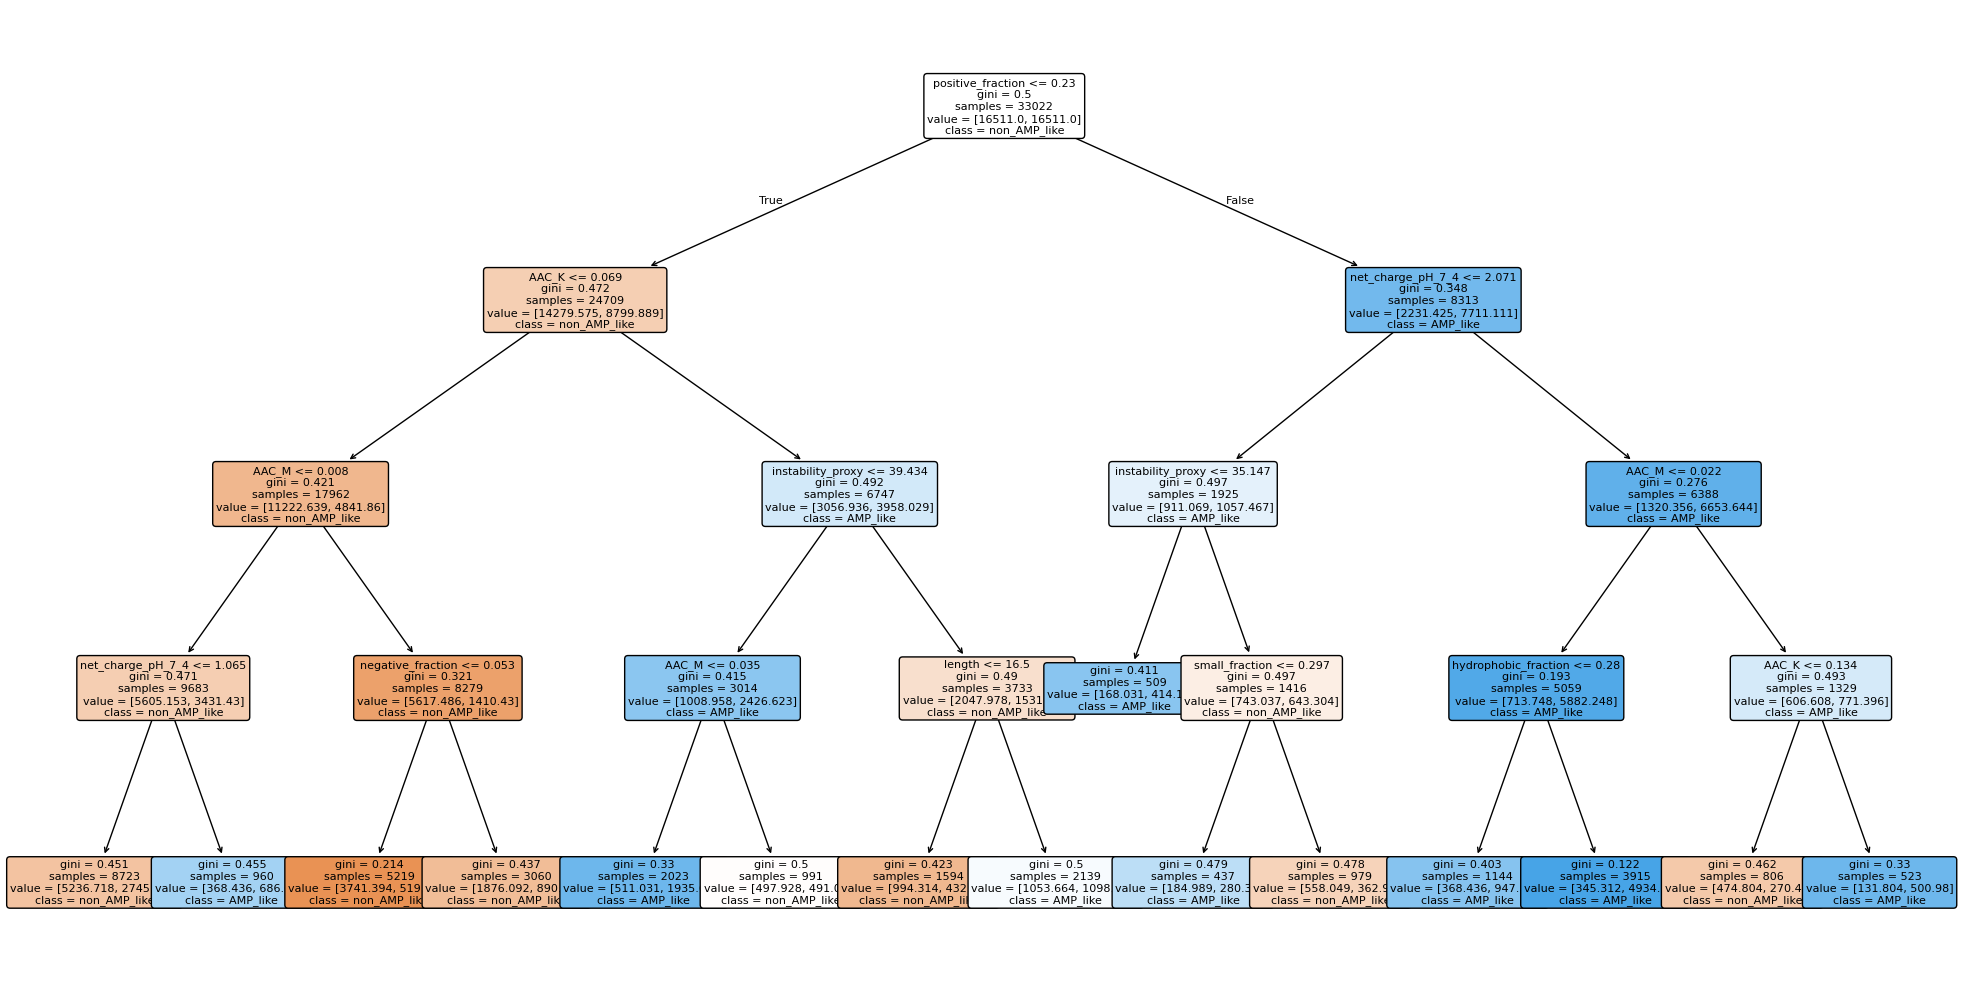

Saved: ../outputs_explainability/rules/surrogate_tree_rules.txt
Saved: ../outputs_explainability/figures/surrogate_tree_rules.png
|--- positive_fraction <= 0.2300
|   |--- AAC_K <= 0.0694
|   |   |--- AAC_M <= 0.0083
|   |   |   |--- net_charge_pH_7_4 <= 1.0651
|   |   |   |   |--- class: 0
|   |   |   |--- net_charge_pH_7_4 >  1.0651
|   |   |   |   |--- class: 1
|   |   |--- AAC_M >  0.0083
|   |   |   |--- negative_fraction <= 0.0531
|   |   |   |   |--- class: 0
|   |   |   |--- negative_fraction >  0.0531
|   |   |   |   |--- class: 0
|   |--- AAC_K >  0.0694
|   |   |--- instability_proxy <= 39.4338
|   |   |   |--- AAC_M <= 0.0348
|   |   |   |   |--- class: 1
|   |   |   |--- AAC_M >  0.0348
|   |   |   |   |--- class: 0
|   |   |--- instability_proxy >  39.4338
|   |   |   |--- length <= 16.5000
|   |   |   |   |--- class: 0
|   |   |   |--- length >  16.5000
|   |   |   |   |--- class: 1
|--- positive_fraction >  0.2300
|   |--- net_charge_pH_7_4 <= 2.0706
|   |   |--- instab

In [15]:
# ============================================================
# 15. Export surrogate tree rules and plot
# ============================================================

surrogate_rules_text = export_text(
    surrogate_tree,
    feature_names=DESCRIPTOR_COLS,
    decimals=4,
)

rules_txt_path = RULE_DIR / "surrogate_tree_rules.txt"
with open(rules_txt_path, "w") as f:
    f.write(surrogate_rules_text)

plt.figure(figsize=(20, 10))
plot_tree(
    surrogate_tree,
    feature_names=DESCRIPTOR_COLS,
    class_names=["non_AMP_like", "AMP_like"],
    filled=True,
    rounded=True,
    max_depth=SURROGATE_TREE_DEPTH,
    fontsize=8,
)
plt.tight_layout()

tree_fig_path = FIGURE_DIR / "surrogate_tree_rules.png"
plt.savefig(tree_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rules_txt_path)
print("Saved:", tree_fig_path)
print(surrogate_rules_text[:4000])

In [16]:
# ============================================================
# 16. Export surrogate feature importance
# ============================================================

surrogate_importance_df = pd.DataFrame({
    "feature": DESCRIPTOR_COLS,
    "surrogate_importance": surrogate_tree.feature_importances_,
}).sort_values("surrogate_importance", ascending=False)

surrogate_importance_path = RULE_DIR / "surrogate_tree_feature_importance.csv"
surrogate_importance_df.to_csv(surrogate_importance_path, index=False)

print("Saved:", surrogate_importance_path)
surrogate_importance_df.head(20)

Saved: ../outputs_explainability/rules/surrogate_tree_feature_importance.csv


,feature,surrogate_importance
7,positive_fraction,0.460082
29,AAC_K,0.170453
31,AAC_M,0.133516
4,net_charge_pH_7_4,0.096703
17,instability_proxy,0.068583
8,negative_fraction,0.028598
11,hydrophobic_fraction,0.020646
0,length,0.015700
14,small_fraction,0.005720
5,absolute_charge_pH_7_4,0.000000


## 10. Combined explainability evidence table

This table integrates SHAP importance, directionality, candidate ranges, and surrogate-tree importance. It is the main bridge between this explainability notebook and the next rule-based prioritisation notebook.

In [17]:
# ============================================================
# 17. Build combined rule-evidence table
# ============================================================

combined_evidence_df = global_importance_df.merge(
    candidate_rules_df[[
        "feature",
        "candidate_rule_from_confident_amp_like_region",
        "selected_q25",
        "selected_median",
        "selected_q75",
        "background_median",
    ]],
    on="feature",
    how="left",
).merge(
    surrogate_importance_df,
    on="feature",
    how="left",
)

combined_evidence_df["surrogate_importance"] = combined_evidence_df["surrogate_importance"].fillna(0.0)

combined_evidence_path = RULE_DIR / "combined_explainability_rule_evidence.csv"
combined_evidence_df.to_csv(combined_evidence_path, index=False)

print("Saved:", combined_evidence_path)
combined_evidence_df.head(TOP_N_FEATURES)

Saved: ../outputs_explainability/rules/combined_explainability_rule_evidence.csv


,feature,mean_abs_shap,mean_shap,median_shap,spearman_raw_value_vs_shap,spearman_p_value,interpretable_direction,raw_median,raw_q25,raw_q75,candidate_rule_from_confident_amp_like_region,selected_q25,selected_median,selected_q75,background_median,surrogate_importance
0,AAC_K,0.044008,0.002915,-0.012617,0.850375,1.450929e-280,higher_values_support_AMP_prediction,0.051282,0.000000,0.133333,AAC_K >= 0.08333,0.083333,0.222222,0.352941,0.045455,0.170453
1,AAC_M,0.035435,-0.000409,0.014601,-0.825355,5.410361e-250,lower_values_support_AMP_prediction,0.000000,0.000000,0.035244,AAC_M <= 0,0.000000,0.000000,0.000000,0.000000,0.133516
2,isoelectric_point_approx,0.032766,0.003684,0.006249,0.538873,2.140046e-76,higher_values_support_AMP_prediction,9.910000,6.020000,11.220000,isoelectric_point_approx >= 10.84,10.840000,11.210000,12.000000,9.640000,0.000000
3,positive_fraction,0.030998,0.001587,-0.008039,0.851123,1.457752e-281,higher_values_support_AMP_prediction,0.153846,0.088106,0.263158,positive_fraction >= 0.2857,0.285714,0.375000,0.461538,0.150000,0.460082
4,small_fraction,0.020585,-0.000705,-0.007268,-0.726056,1.675945e-164,lower_values_support_AMP_prediction,0.500000,0.357143,0.592593,small_fraction <= 0.3333,0.000000,0.166667,0.333333,0.500000,0.005720
5,polar_fraction,0.018879,-0.001109,-0.004768,-0.779280,9.108957e-205,lower_values_support_AMP_prediction,0.222222,0.125000,0.333333,polar_fraction <= 0.1,0.000000,0.000000,0.100000,0.230769,0.000000
6,unique_residue_fraction,0.018787,-0.000580,0.000999,-0.728051,7.753426e-166,lower_values_support_AMP_prediction,0.516685,0.380952,0.666667,unique_residue_fraction <= 0.5385,0.300000,0.416667,0.538462,0.526316,0.000000
7,AAC_S,0.018572,-0.000430,0.003952,-0.783227,3.361839e-208,lower_values_support_AMP_prediction,0.045455,0.000000,0.100000,AAC_S <= 0,0.000000,0.000000,0.000000,0.055556,0.000000
8,net_charge_pH_7_4,0.017311,-0.000468,-0.001618,0.771348,4.430871e-198,higher_values_support_AMP_prediction,1.338777,-0.009076,3.992259,net_charge_pH_7_4 >= 2.994,2.994097,3.994874,5.990144,0.994898,0.096703
9,charged_fraction,0.016490,-0.000920,-0.000891,0.738873,2.731323e-173,higher_values_support_AMP_prediction,0.226136,0.150000,0.333333,charged_fraction >= 0.3,0.300000,0.384615,0.461538,0.222222,0.000000


In [18]:
# ============================================================
# 18. Optional: create a compact manuscript-ready summary table
# ============================================================

summary_cols = [
    "feature",
    "mean_abs_shap",
    "interpretable_direction",
    "candidate_rule_from_confident_amp_like_region",
    "surrogate_importance",
]

manuscript_summary_df = combined_evidence_df[summary_cols].head(12).copy()

manuscript_summary_path = TABLE_DIR / "manuscript_ready_explainability_summary.csv"
manuscript_summary_df.to_csv(manuscript_summary_path, index=False)

print("Saved:", manuscript_summary_path)
manuscript_summary_df

Saved: ../outputs_explainability/tables/manuscript_ready_explainability_summary.csv


,feature,mean_abs_shap,interpretable_direction,candidate_rule_from_confident_amp_like_region,surrogate_importance
0,AAC_K,0.044008,higher_values_support_AMP_prediction,AAC_K >= 0.08333,0.170453
1,AAC_M,0.035435,lower_values_support_AMP_prediction,AAC_M <= 0,0.133516
2,isoelectric_point_approx,0.032766,higher_values_support_AMP_prediction,isoelectric_point_approx >= 10.84,0.000000
3,positive_fraction,0.030998,higher_values_support_AMP_prediction,positive_fraction >= 0.2857,0.460082
4,small_fraction,0.020585,lower_values_support_AMP_prediction,small_fraction <= 0.3333,0.005720
5,polar_fraction,0.018879,lower_values_support_AMP_prediction,polar_fraction <= 0.1,0.000000
6,unique_residue_fraction,0.018787,lower_values_support_AMP_prediction,unique_residue_fraction <= 0.5385,0.000000
7,AAC_S,0.018572,lower_values_support_AMP_prediction,AAC_S <= 0,0.000000
8,net_charge_pH_7_4,0.017311,higher_values_support_AMP_prediction,net_charge_pH_7_4 >= 2.994,0.096703
9,charged_fraction,0.016490,higher_values_support_AMP_prediction,charged_fraction >= 0.3,0.000000


## 11. Export notebook metadata

In [19]:
# ============================================================
# 19. Export explainability metadata
# ============================================================

explainability_metadata = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "training_metadata_path": str(METADATA_PATH),
    "best_model_selection_path": str(BEST_MODEL_PATH),
    "best_model_name": BEST_MODEL_NAME,
    "best_model_artifact": str(model_path),
    "prediction_artifact": str(prediction_path),
    "n_total_samples": int(len(analysis_df)),
    "n_shap_samples": int(len(X_shap_scaled)),
    "n_background_samples": int(len(X_background_scaled)),
    "n_descriptors": int(len(DESCRIPTOR_COLS)),
    "classifier_class": classifier.__class__.__name__,
    "shap_strategy": "TreeExplainer for tree models; LinearExplainer for linear models; model-agnostic fallback otherwise",
    "local_explanation_n": int(len(selected_indices)),
    "surrogate_tree_depth": SURROGATE_TREE_DEPTH,
    "surrogate_min_samples_leaf": int(min_samples_leaf),
    "outputs": {
        "shap_matrix": str(shap_matrix_path),
        "global_importance": str(global_importance_path),
        "candidate_rules": str(candidate_rules_path),
        "surrogate_rules": str(rules_txt_path),
        "combined_evidence": str(combined_evidence_path),
        "manuscript_summary": str(manuscript_summary_path),
    },
}

metadata_out_path = OUTPUT_DIR / "explainability_metadata.json"
with open(metadata_out_path, "w") as f:
    json.dump(explainability_metadata, f, indent=2)

print("Saved:", metadata_out_path)
print("\nGenerated files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print("-", path)

Saved: ../outputs_explainability/explainability_metadata.json

Generated files:
- ../outputs_explainability/explainability_metadata.json
- ../outputs_explainability/figures/shap_dependence_AAC_K.png
- ../outputs_explainability/figures/shap_dependence_AAC_M.png
- ../outputs_explainability/figures/shap_dependence_isoelectric_point_approx.png
- ../outputs_explainability/figures/shap_dependence_polar_fraction.png
- ../outputs_explainability/figures/shap_dependence_positive_fraction.png
- ../outputs_explainability/figures/shap_dependence_small_fraction.png
- ../outputs_explainability/figures/shap_global_importance_barplot.png
- ../outputs_explainability/figures/shap_summary_bar.png
- ../outputs_explainability/figures/shap_summary_beeswarm.png
- ../outputs_explainability/figures/surrogate_tree_rules.png
- ../outputs_explainability/rules/candidate_interpretable_feature_rules_from_shap.csv
- ../outputs_explainability/rules/combined_explainability_rule_evidence.csv
- ../outputs_explainability/r

# Notes for the next notebook

The next notebook can use:

- `outputs_explainability/rules/combined_explainability_rule_evidence.csv`
- `outputs_explainability/rules/candidate_interpretable_feature_rules_from_shap.csv`
- `outputs_training/predictions/<best_model>_predictions_with_uncertainty.csv`

These files allow construction of a rule-aware prioritisation score such as:

\[
\text{Final score} = w_1 P(AMP) + w_2 \text{RuleScore} - w_3 \text{Uncertainty}
\]

where the rules are derived from SHAP directionality, confident AMP-like descriptor ranges, and surrogate-tree evidence.